# NDMC Conductivity MPC Notebook

This notebook presents the NDMC conductivity MPC example bundled with this repository.

It does four things:
- rerun one NDMC closed-loop case built on `build_tracking_mpc(...)`;
- read the saved CSV outputs;
- visualize the closed-loop behavior in a publication-style format;
- inspect the public naming surface exposed by the controller.


In [21]:
using Pkg

repo_root = isdir(joinpath(pwd(), "src")) ? pwd() : normpath(joinpath(pwd(), ".."))
examples_env = joinpath(repo_root, "examples")
examples_project = joinpath(examples_env, "Project.toml")
generated_dir = joinpath(repo_root, "examples", "generated")
style_path = joinpath(repo_root, "notebooks", "eoi_publication_plots.jl")

# Set this to true only when bootstrapping a fresh examples environment.
bootstrap_examples_env = false

if Base.active_project() != examples_project
    Pkg.activate(examples_env; io=devnull)
end

if bootstrap_examples_env || !isfile(joinpath(examples_env, "Manifest.toml"))
    Pkg.instantiate(; io=devnull)
end

using CSV, DataFrames, Plots

include(style_path)
apply_eoi_publication_style!()


## Re-run the NDMC Example

This cell runs `examples/ndmc_conductivity_mpc_demo.jl`.

The default case uses:
- `dt = 20 s`;
- `P = 20`;
- `M = 3`;
- one low-zone influent shock from `2100 s` to `2250 s`;
- one shared `Q_air` manipulated variable.

The figures below use the same disturbance window as the paper-style benchmark discussion.


In [22]:
rerun_closed_loop = true

example_script = joinpath(repo_root, "examples", "ndmc_conductivity_mpc_demo.jl")

if rerun_closed_loop
    cmd = `$(Base.julia_cmd()) --project=$(examples_env) $example_script`
    run(cmd)
end


  Activating project at `/Volumes/Lexar/Dropbox/Research/Wastewater Treatment/Wastewater Treatment Repo/EOptInterface/EOptInterface.jl/examples`



******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

Saved NDMC example outputs to:
  /Volumes/Lexar/Dropbox/Research/Wastewater Treatment/Wastewater Treatment Repo/EOptInterface/EOptInterface.jl/examples/generated/ndmc_conductivity_eopt_closed_loop.csv
  /Volumes/Lexar/Dropbox/Research/Wastewater Treatment/Wastewater Treatment Repo/EOptInterface/EOptInterface.jl/examples/generated/ndmc_conductivity_eopt_applied_control.csv
  /Volumes/Lexar/Dropbox/Research/Wastewater Treatment/Wastewater Treatment Repo/EOptInterface/EOptInterface.jl/examples/generated/ndmc_conductivity_eopt_name_map.csv


Process(`/Users/xupengfei/.julia/juliaup/julia-1.12.4+0.aarch64.apple.darwin14/bin/julia -C native -J/Users/xupengfei/.julia/juliaup/julia-1.12.4+0.aarch64.apple.darwin14/lib/julia/sys.dylib -g1 --color=yes '--project=/Volumes/Lexar/Dropbox/Research/Wastewater Treatment/Wastewater Treatment Repo/EOptInterface/EOptInterface.jl/examples' '/Volumes/Lexar/Dropbox/Research/Wastewater Treatment/Wastewater Treatment Repo/EOptInterface/EOptInterface.jl/examples/ndmc_conductivity_mpc_demo.jl'`, ProcessExited(0))

In [23]:
closed_loop_path = joinpath(generated_dir, "ndmc_conductivity_eopt_closed_loop.csv")
applied_path = joinpath(generated_dir, "ndmc_conductivity_eopt_applied_control.csv")
name_map_path = joinpath(generated_dir, "ndmc_conductivity_eopt_name_map.csv")

isfile(closed_loop_path) || error("Missing $(closed_loop_path). Run the example cell first.")
isfile(applied_path) || error("Missing $(applied_path). Run the example cell first.")
isfile(name_map_path) || error("Missing $(name_map_path). Run the example cell first.")

closed_loop = CSV.read(closed_loop_path, DataFrame)
applied = CSV.read(applied_path, DataFrame)
name_map = CSV.read(name_map_path, DataFrame)

first(closed_loop, 5)

Row,time,C1,C2,C3,Cmix,cO,Q_air
,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,0.0,280.0,280.0,280.0,280.0,0.0,439.221
2,20.0,280.116,280.116,280.116,280.116,0.189285,300.46
3,40.0,280.02,280.02,280.02,280.019,0.244632,48.1608
4,60.0,279.958,279.958,279.958,279.958,0.160198,107.763
5,80.0,279.986,279.986,279.986,279.985,0.131418,193.796


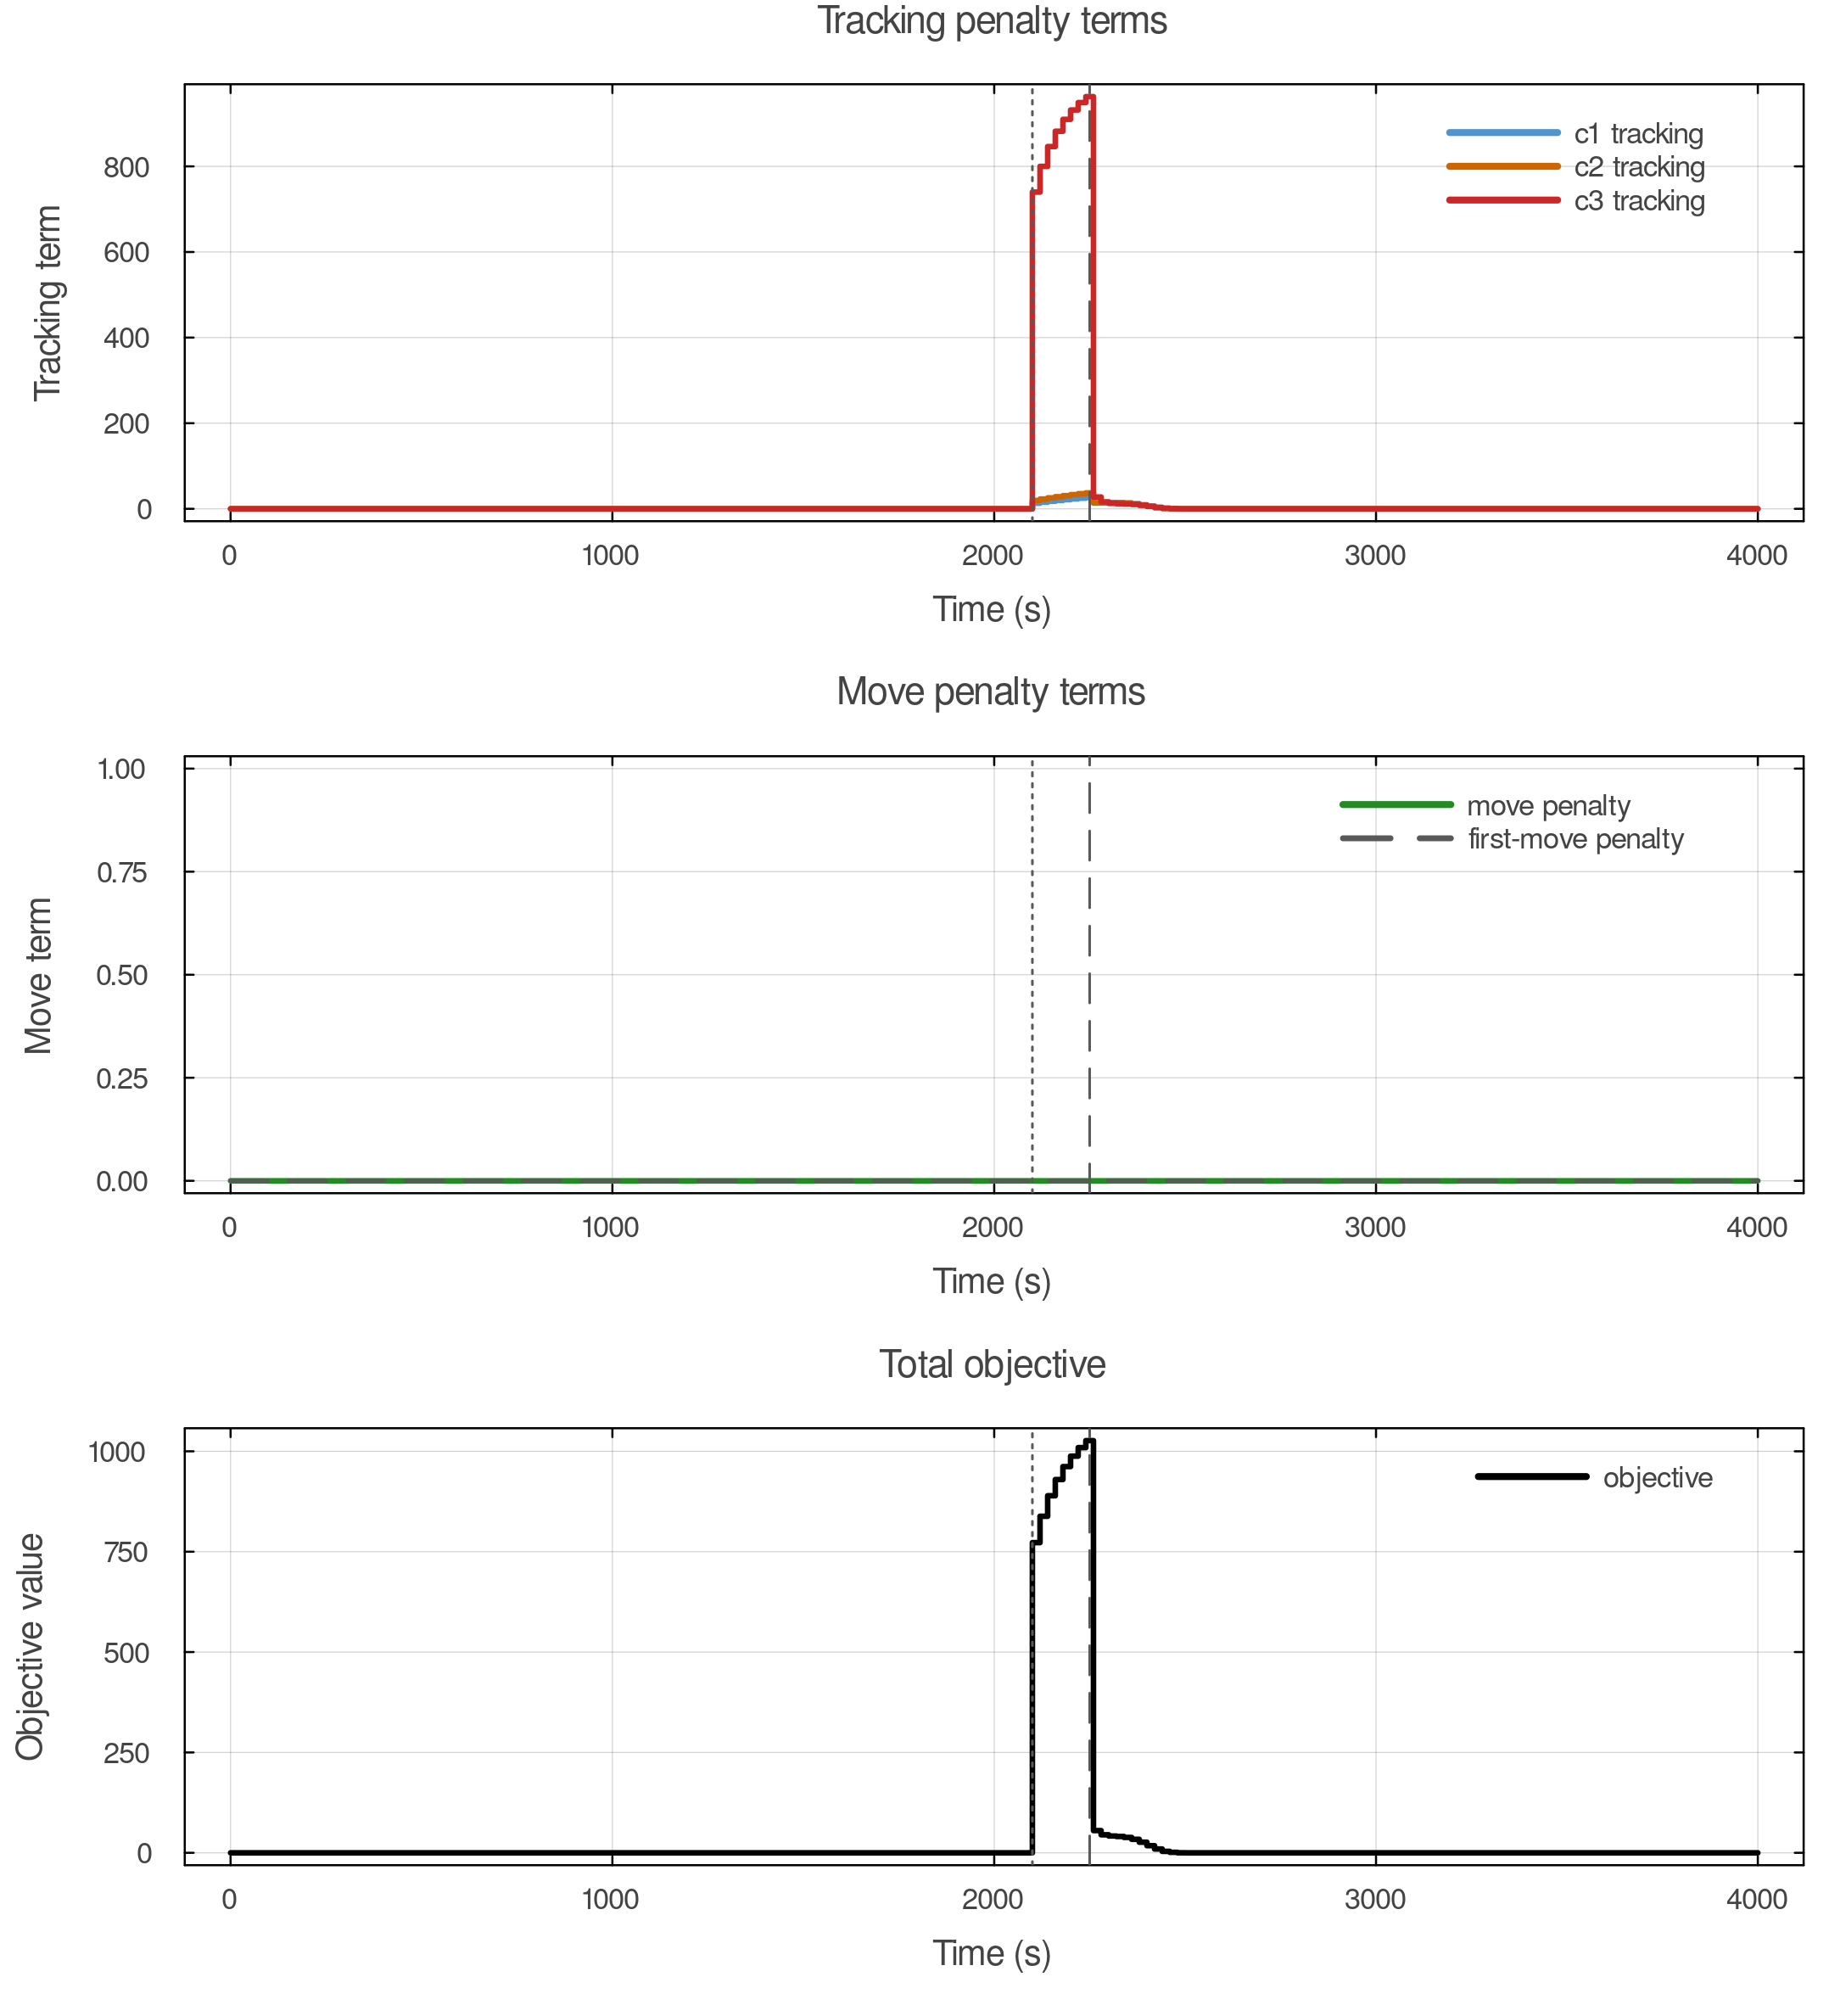

In [24]:
ndmc_plot_penalty_terms(applied; disturbance_window = NDMC_NOTEBOOK_PLOT_CONFIG.disturbance_window)


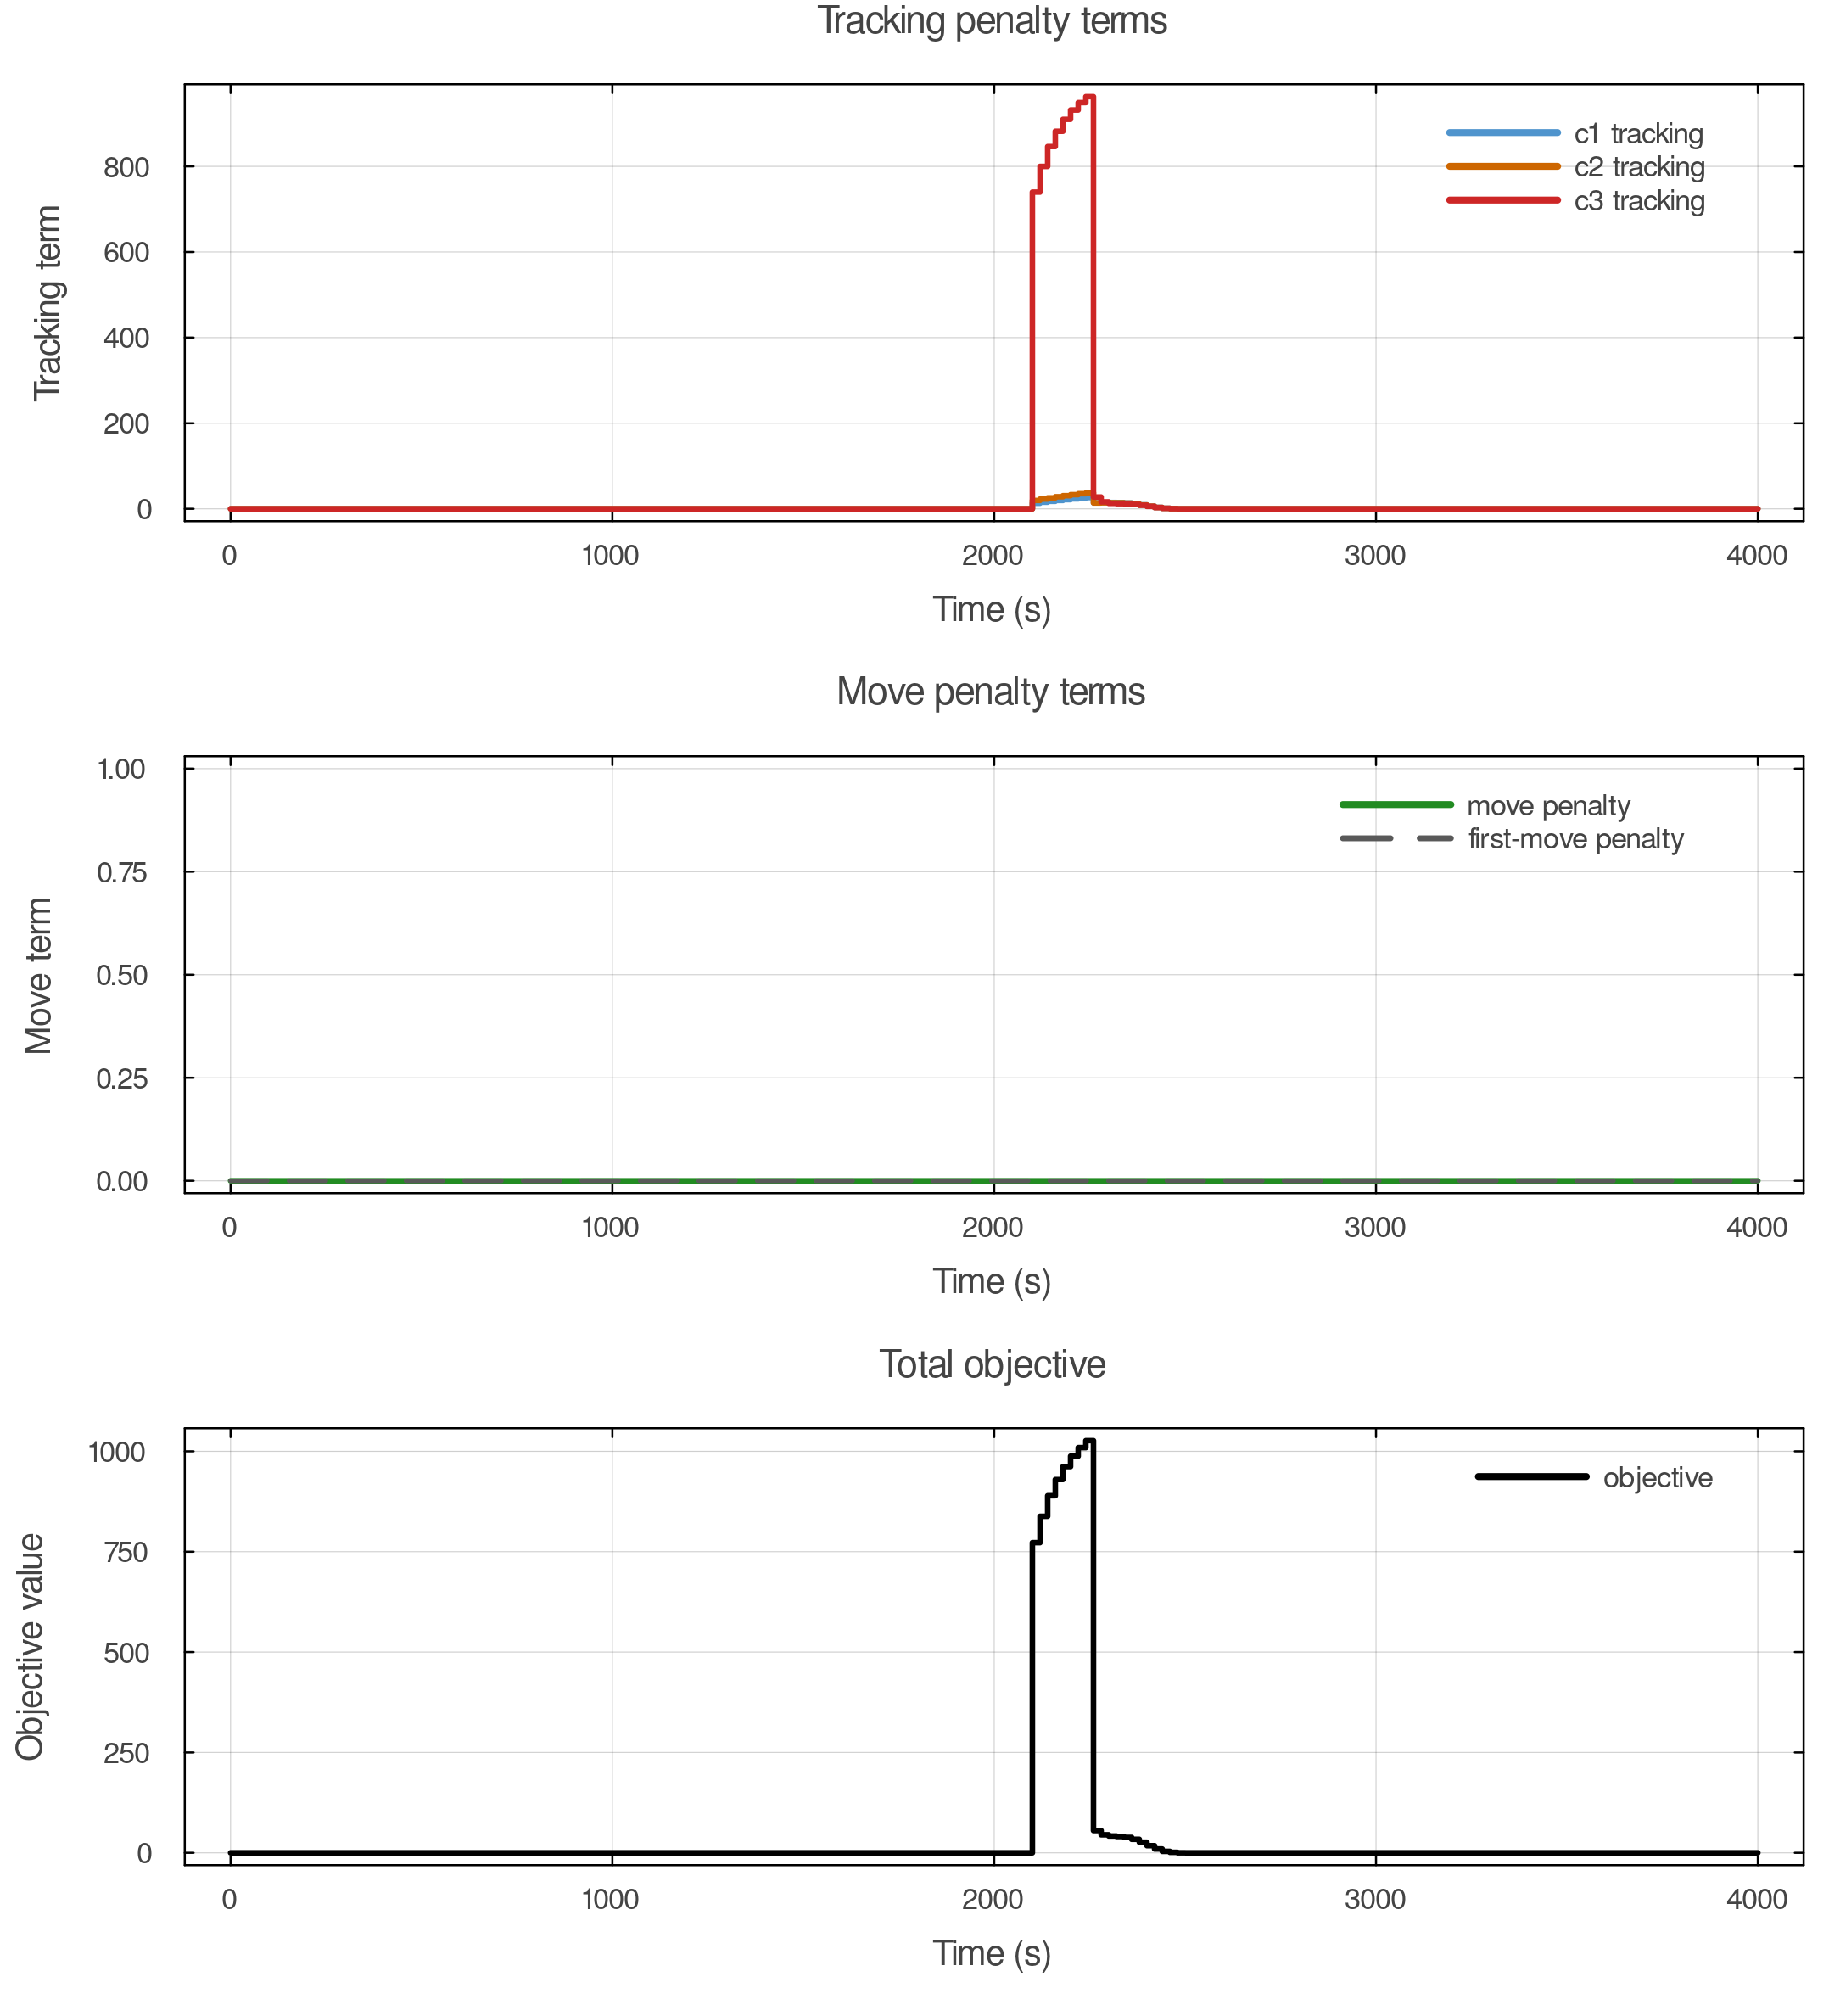

In [25]:
ndmc_plot_penalty_terms(applied)


## Public Naming Surface Used by the NDMC Example

This example does not hand-build JuMP names.
Instead, it passes `base_name` through `MPCControlSpec` and `MPCOutputSpec`, then reuses the public naming maps stored in the controller.

That matters for two reasons:
- the example stays cleaner;
- downstream code can still find the right trajectory by a human-readable name.


In [26]:
name_map


Row,category,symbol,base_name
,String7,String7,String7
1,control,Q_air,Q_air
2,output,C1(t),C1
3,output,C2(t),C2
4,output,C3(t),C3


## Compare with Chenyu's Legacy DMC Baseline

This section compares the current EOptInterface MPC result with Chenyu's legacy DMC implementation in `examples/MPC_NDMC.jl`.

It keeps the same low-zone shock benchmark and uses the same paper-style disturbance window for the focused comparison plots.
The comparison data are stored in `examples/generated`, and the cell below can refresh them if the current MPC result or the legacy script changes.


In [27]:
rerun_legacy_comparison = false

legacy_script = joinpath(repo_root, "examples", "MPC_NDMC.jl")
legacy_generator = joinpath(repo_root, "examples", "generate_ndmc_legacy_comparison.jl")
legacy_summary_path = joinpath(generated_dir, "ndmc_vs_legacy_summary_10s.csv")
legacy_path = joinpath(generated_dir, "legacy_mpc_ndmc_closed_loop_10s.csv")
comparison_path = joinpath(generated_dir, "ndmc_vs_legacy_comparison_10s.csv")

comparison_outputs = [legacy_summary_path, legacy_path, comparison_path]
comparison_inputs = [closed_loop_path, legacy_script, legacy_generator]

comparison_outputs_ready = all(isfile, comparison_outputs)
comparison_outputs_stale = !comparison_outputs_ready || maximum(stat(path).mtime for path in comparison_inputs) > minimum(stat(path).mtime for path in comparison_outputs)
rerun_legacy_comparison = rerun_legacy_comparison || comparison_outputs_stale

if rerun_legacy_comparison
    cmd = `$(Base.julia_cmd()) --project=$(examples_env) $legacy_generator $closed_loop_path $legacy_path $comparison_path $legacy_summary_path`
    run(cmd)
end



******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************



Process(`/Users/xupengfei/.julia/juliaup/julia-1.12.4+0.aarch64.apple.darwin14/bin/julia -C native -J/Users/xupengfei/.julia/juliaup/julia-1.12.4+0.aarch64.apple.darwin14/lib/julia/sys.dylib -g1 --color=yes '--project=/Volumes/Lexar/Dropbox/Research/Wastewater Treatment/Wastewater Treatment Repo/EOptInterface/EOptInterface.jl/examples' '/Volumes/Lexar/Dropbox/Research/Wastewater Treatment/Wastewater Treatment Repo/EOptInterface/EOptInterface.jl/examples/generate_ndmc_legacy_comparison.jl' '/Volumes/Lexar/Dropbox/Research/Wastewater Treatment/Wastewater Treatment Repo/EOptInterface/EOptInterface.jl/examples/generated/ndmc_conductivity_eopt_closed_loop.csv' '/Volumes/Lexar/Dropbox/Research/Wastewater Treatment/Wastewater Treatment Repo/EOptInterface/EOptInterface.jl/examples/generated/legacy_mpc_ndmc_closed_loop_10s.csv' '/Volumes/Lexar/Dropbox/Research/Wastewater Treatment/Wastewater Treatment Repo/EOptInterface/EOptInterface.jl/examples/generated/ndmc_vs_legacy_comparison_10s.csv' '/Vo

In [28]:
legacy_summary = CSV.read(legacy_summary_path, DataFrame)
legacy_summary


Row,metric,value
,String31,Float64
1,RMSE diff C1,0.575516
2,RMSE diff C2,0.575521
3,RMSE diff C3,0.575513
4,RMSE diff Cmix,0.57557
5,RMSE diff cO,0.251921
6,RMSE diff Q,143.777
7,Max abs diff C1,3.18495
8,Max abs diff C2,3.18498
9,Max abs diff C3,3.18497


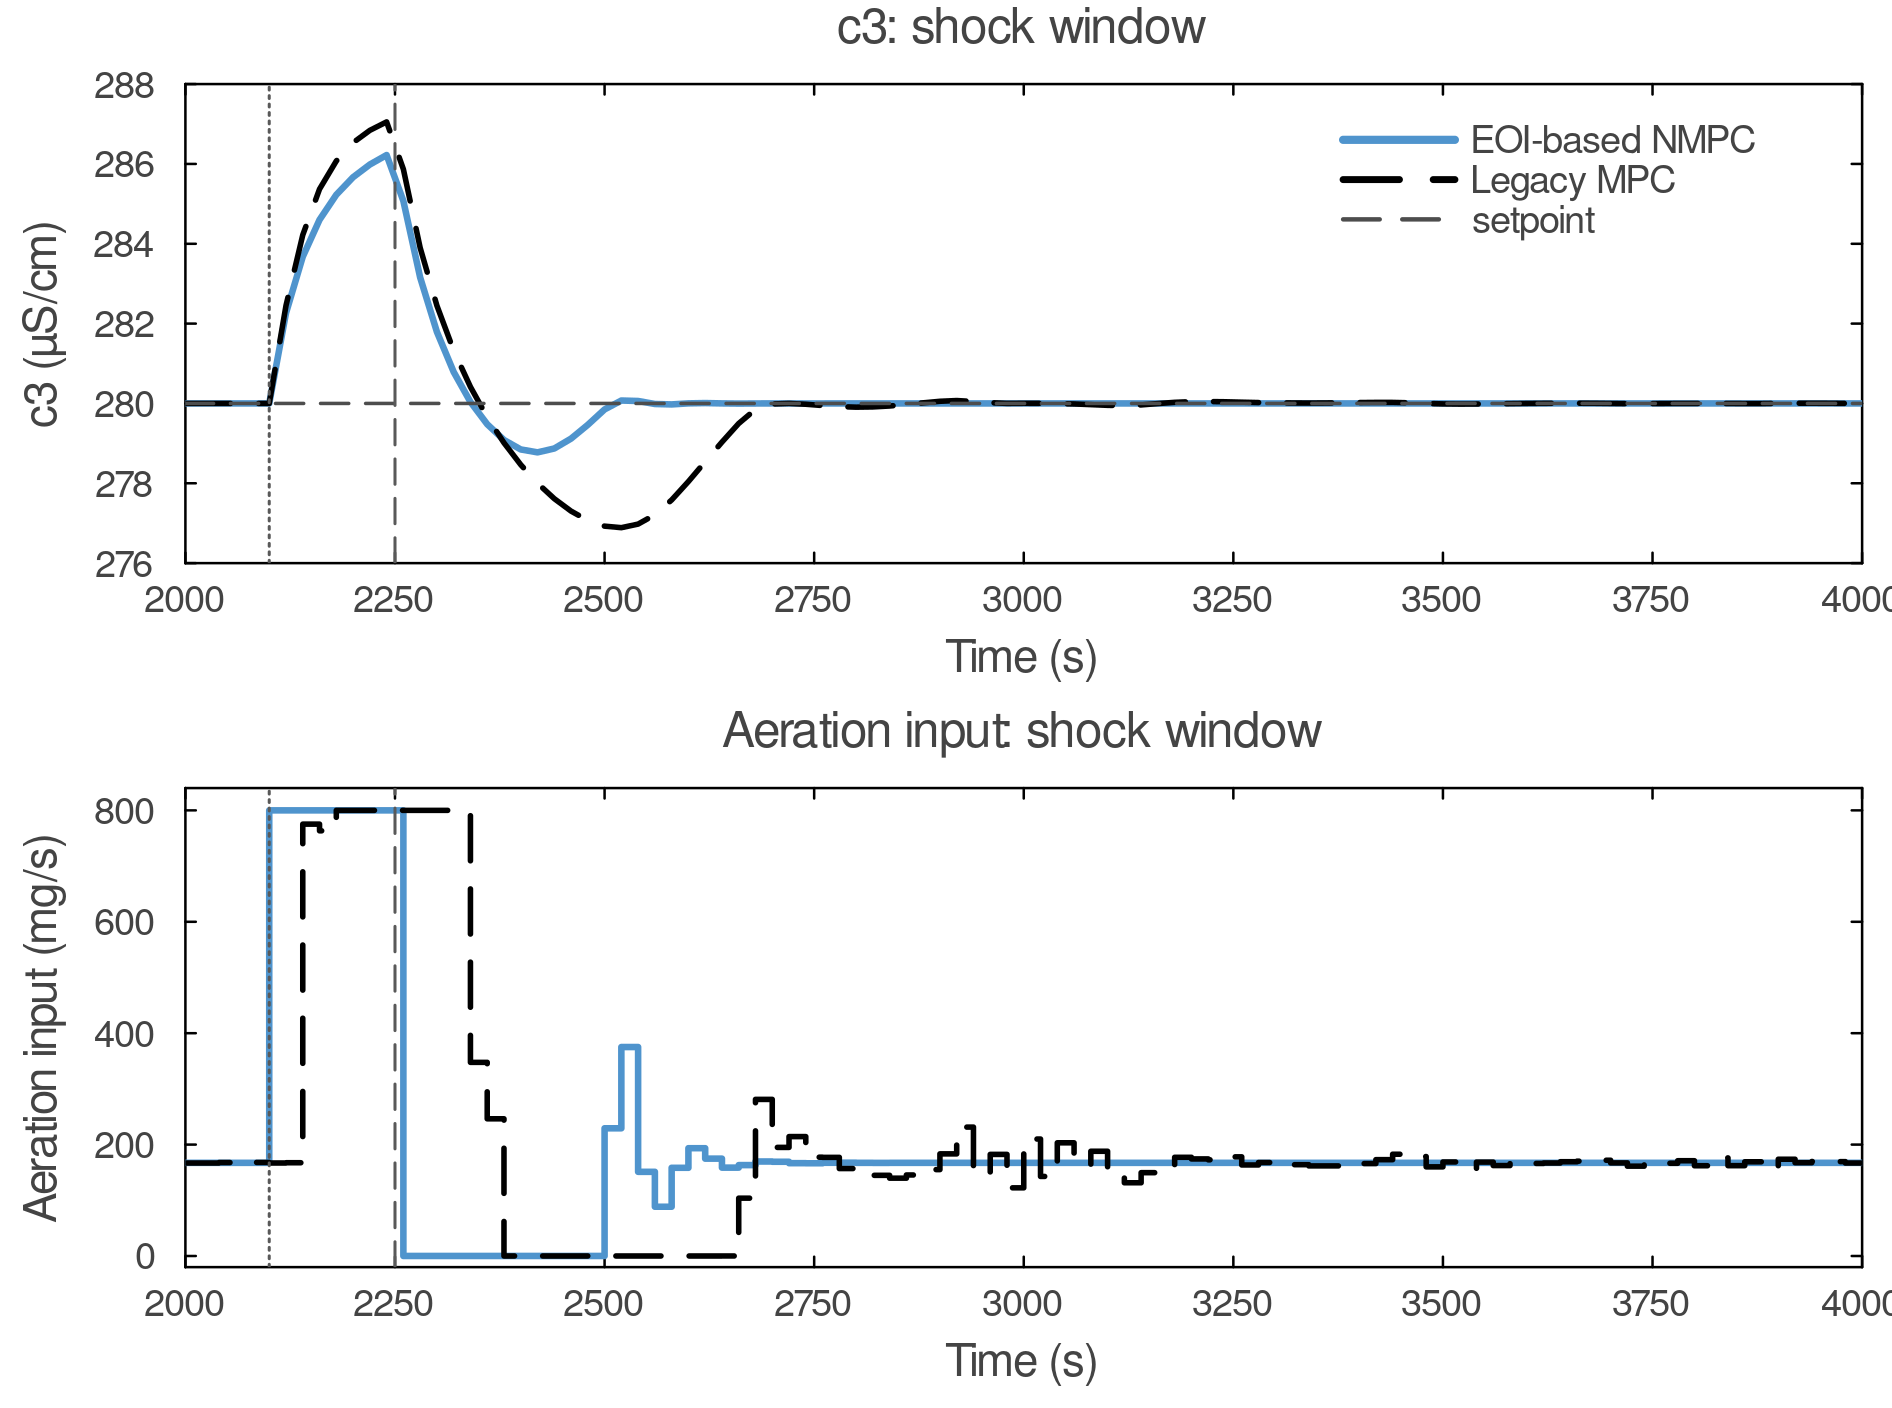

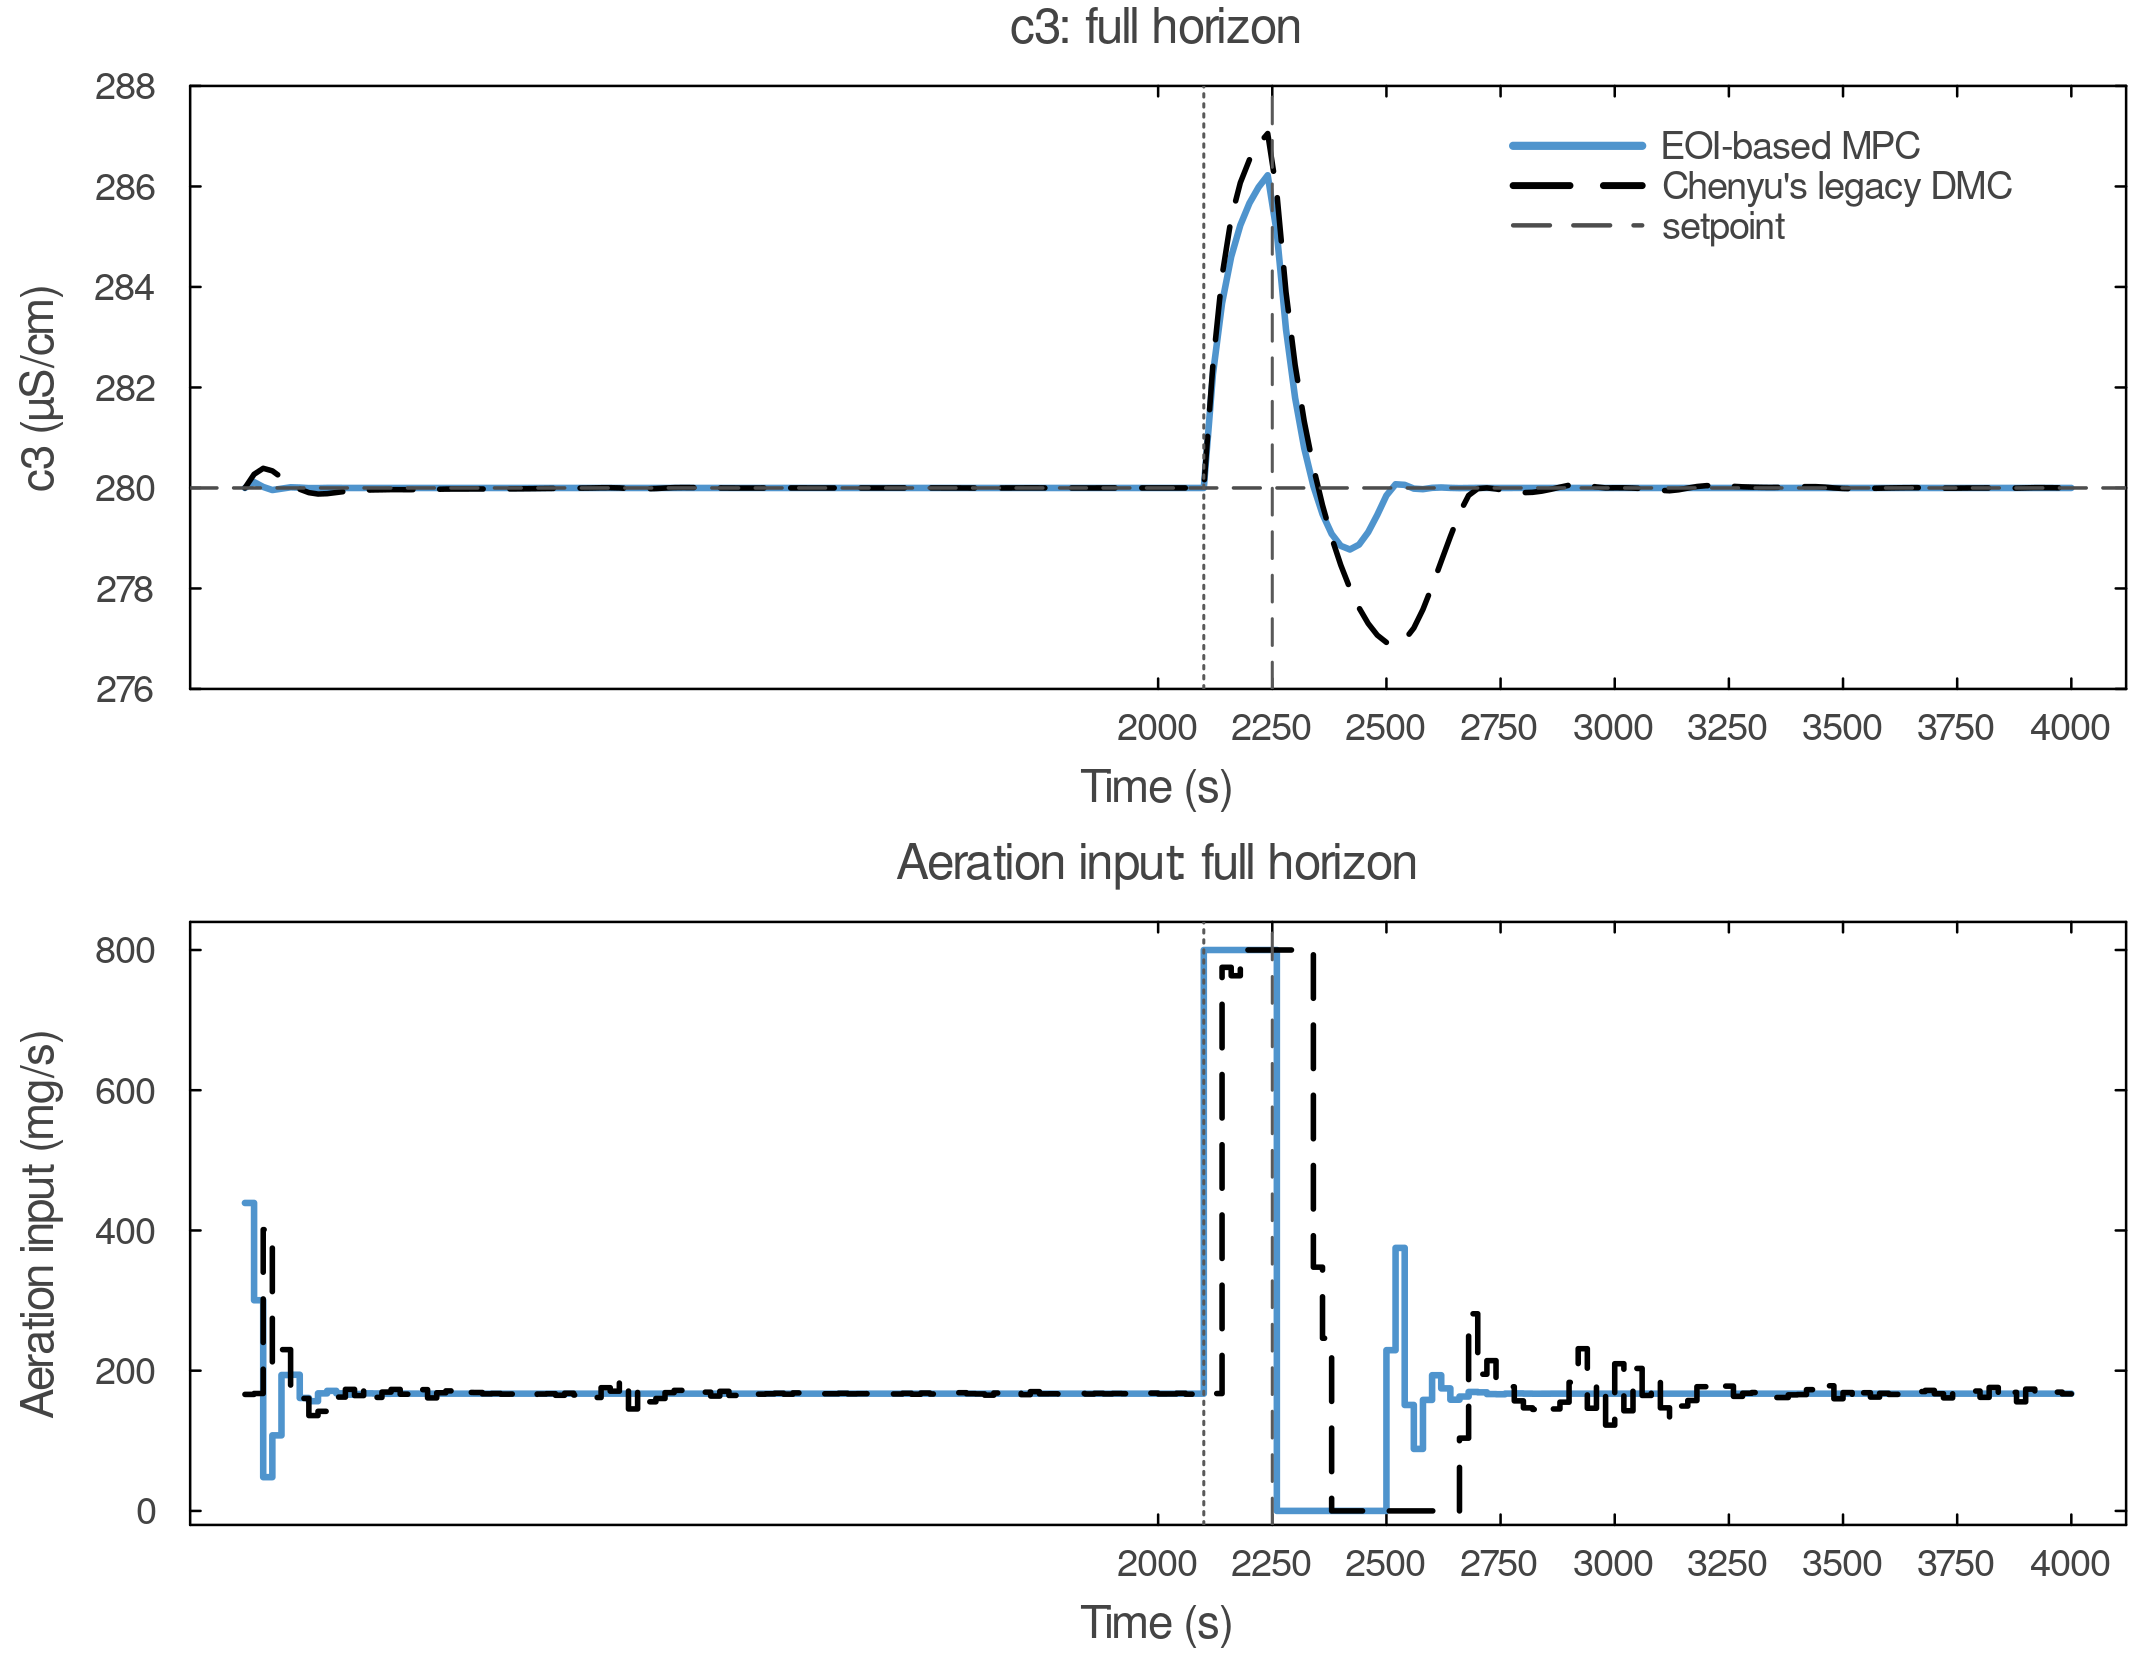

In [29]:
legacy_closed_loop = CSV.read(legacy_path, DataFrame)

shock_window = NDMC_PLOT_CONFIG.shock_window
disturbance_window = NDMC_PLOT_CONFIG.disturbance_window

paper_pair = ndmc_plot_shock_window_pair(
    closed_loop,
    legacy_closed_loop;
    tspan = shock_window,
    disturbance_window = disturbance_window,
)
full_pair = ndmc_plot_legacy_comparison_pair(
    closed_loop,
    legacy_closed_loop;
    disturbance_window = disturbance_window,
    title_suffix = "full horizon",
)

display(paper_pair)
full_pair


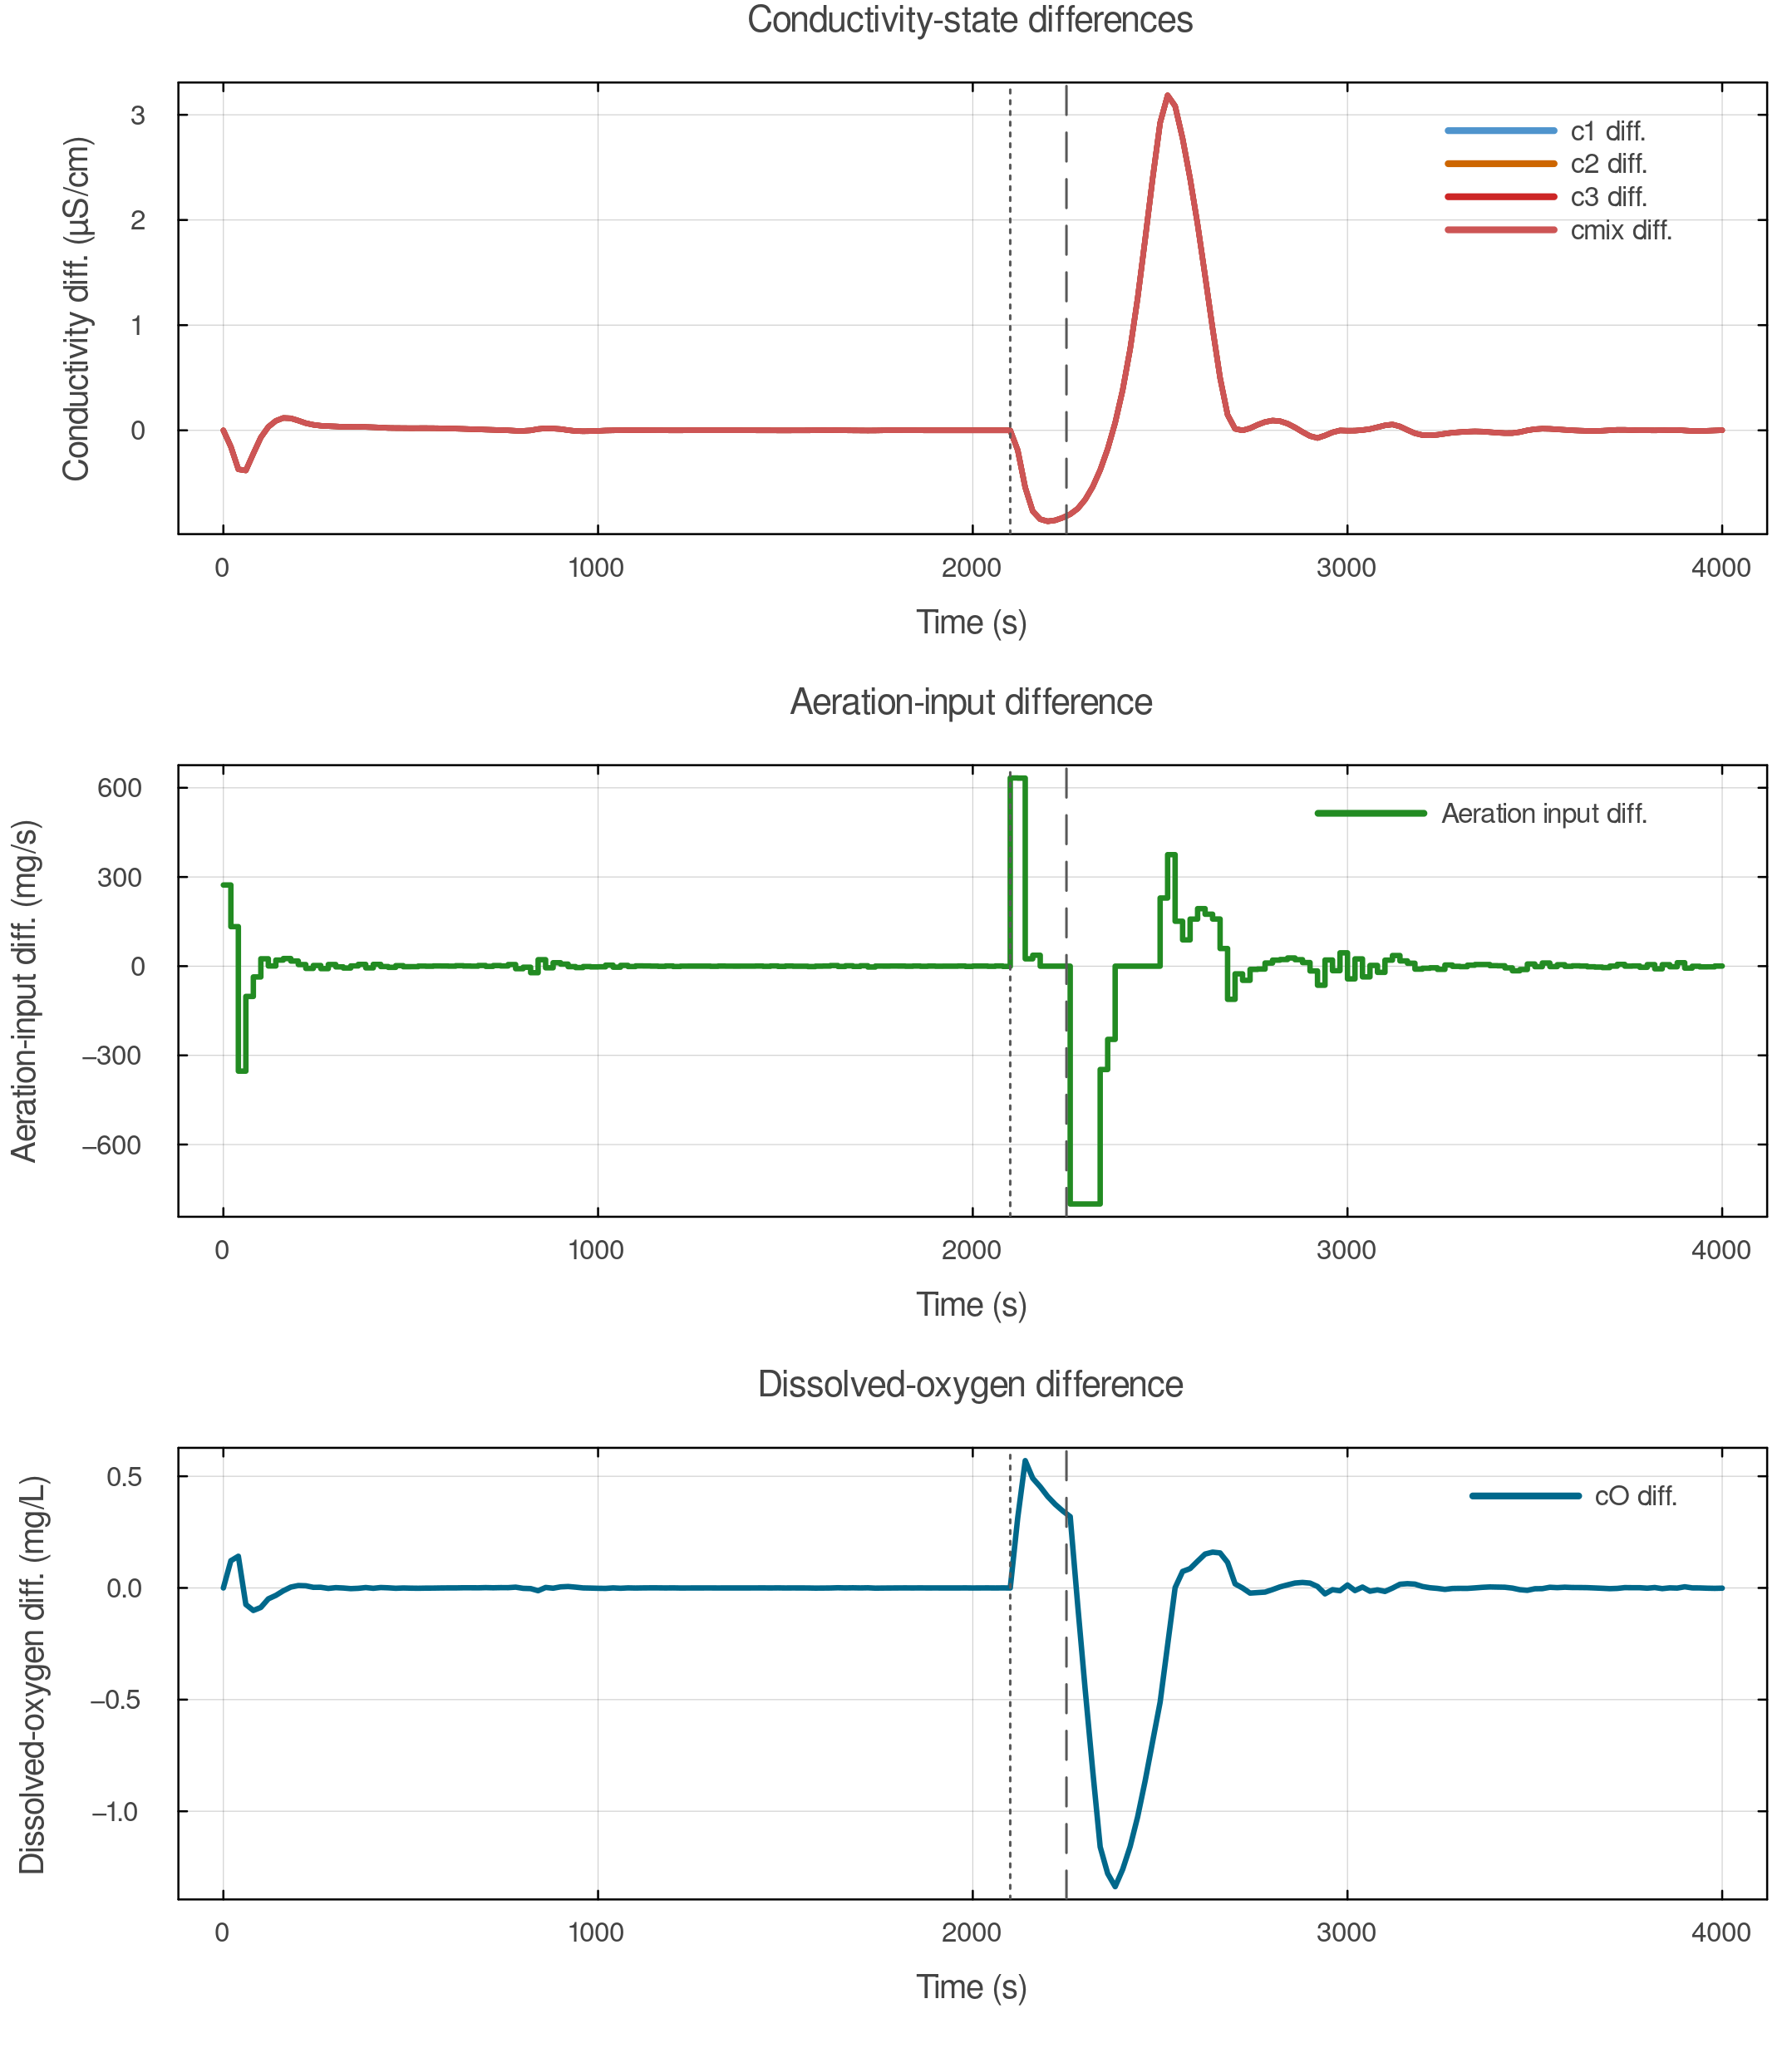

In [30]:
comparison_df = CSV.read(comparison_path, DataFrame)
ndmc_plot_difference_pair(comparison_df; disturbance_window = NDMC_PLOT_CONFIG.disturbance_window)
